In [37]:
from pathlib import Path
import selfmadefunctions
import importlib
import matplotlib.pyplot as plt
import numpy as np
importlib.reload(selfmadefunctions)

# Author: Manou Liesker. Student number: 15250946

Selfmadefuntions imported/reloaded


<module 'selfmadefunctions' from 'c:\\Users\\DTA180363\\Documents\\GitHub\\paperstack\\Manou_version\\code\\selfmadefunctions.py'>

The cell below is used to read and track the videos, and save the y-coordinates into a CSV file (the y coordinates are already normalized). 

Having problems? Look at the outputfolder to see what part of tracking went wrong. Tweak the function accordingly 

(within selfmadefunctions.py there is a variabele named "treshold_value", that's probably the one to tweak. It might be worth it to make treshold_value one of the input parameters instead of a set value within the function).

In [58]:
importlib.reload(selfmadefunctions)

inputfolder = Path(r"Z:\Video_files\Experiments\Raw_Videos\Distance_From_Edge_300t")
outputfolder = Path(r"Z:\Video_files\Experiments\Tracked_Videos\Distance_From_Edge_300t")
csvfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t")

for i in range(7, 8):
    for j in range(2, 3):
        filename = f"20h_300t_{i}cm_{j}.avi"
        print(filename)
        selfmadefunctions.track_video(100, video_inputfolder=inputfolder, 
                                video_outputfolder=outputfolder, 
                                csv_outputfolder=csvfolder, filename=filename, 
                                show=False, save_video=False, save_csv=True, BOTTOM_CROP = 55)

Selfmadefuntions imported/reloaded
20h_300t_7cm_2.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t\20h_300t_7cm_2_clean.csv


The function COR_calculator_general is meant to be able to read a clean csv file, and be given the name of the variable you are changing (such as thickness etc.) to ouput graphs (if Find_Plot = true) to check if everything went right. The function returns the calculated COR.

In [75]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge")

variable_type = "distance from edge"
edge_100t = [i for i in range(2, 16) for _ in range(1, 4)]
COR_100t = []

for i in range(2, 16):
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_100t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_100t.append(cor_value)



COR_100t[7] = np.nan #Mask weird value

edge_100t, COR_100t, COR_err_100t, avg_COR_100t, edge_unique = selfmadefunctions.get_avg_err(edge_100t, COR_100t)





Selfmadefuntions imported/reloaded


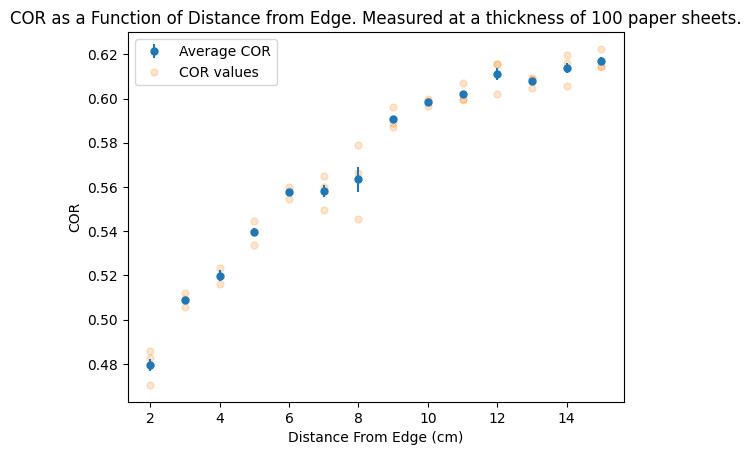

In [77]:
plt.errorbar(edge_unique, avg_COR_100t, yerr=COR_err_100t, fmt = 'o', markersize=5, label='Average COR', zorder = 2)
plt.errorbar(edge_100t, COR_100t, fmt = 'o', markersize=5, label='COR values', zorder = 1, alpha = 0.2)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 100 paper sheets.')
plt.legend()
plt.show()

Selfmadefuntions imported/reloaded


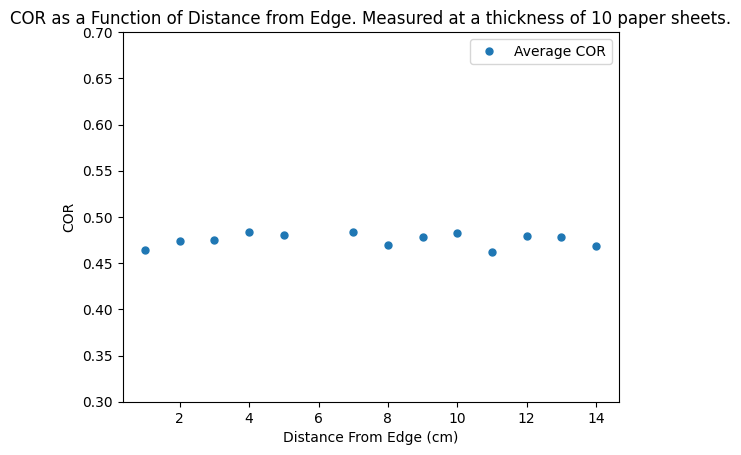

In [19]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_10t")

variable_type = "distance from edge"
x = [i for i in range(1, 15)]
COR = []

for i in range(1, 15):
    variable_value = f"{i} cm"
    
    for j in range(1, 2):
        filename = f"20h_10t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR.append(cor_value)


plt.errorbar(x, COR, fmt = 'o', markersize=5, label='Average COR', zorder = 2)
plt.ylim(0.3, 0.7)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 10 paper sheets.')
plt.legend()
plt.show()

In [83]:
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t")

variable_type = "distance from edge"
edge_300t = np.repeat(np.arange(2, 16), 3)
COR_300t = []

for i in range(2, 16):
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_300t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_300t.append(cor_value)

COR_300t[16] = np.nan
COR_300t[20] = np.nan


In [1]:
importlib.reload(selfmadefunctions)
edge_300t_clean, COR_300t_clean, COR_300t_err, avg_COR_300t, x_unique = selfmadefunctions.get_avg_err(edge_300t, COR_300t)


plt.errorbar(x_unique, avg_COR_300t, COR_300t_err, fmt = 'o', zorder = 2)
plt.errorbar(edge_300t_clean, COR_300t_clean, fmt = 'o', alpha = 0.2, zorder = 1)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 300 paper sheets.')
plt.show()

NameError: name 'importlib' is not defined